# Module 6 — Day 2: Random Forests and Ensemble Methods
## PHY 657, Spring 2026

---

### Recap from Day 1

Last time we built decision trees — classifiers that work by asking a sequence of yes/no questions about individual features. We saw that:

- Trees are highly interpretable: you can read every decision
- Trees handle non-linearity naturally (unlike logistic regression)
- But single trees **overfit badly** when grown too deep

Today's key insight: **one tree is fragile, but many trees averaged together are robust.** This is the idea behind **ensemble methods**, and it leads to random forests — one of the most successful algorithms in applied machine learning.

### Plan
1. Why ensembles work: variance reduction
2. Bagging: bootstrap aggregating
3. Random forests: bagging + random feature subsets
4. Out-of-bag estimation
5. Feature importance
6. Application to Ising data and comparison with previous methods

---
## Part 0: Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})
RNG = np.random.default_rng(42)

cmap_bg = ListedColormap(['#AEDDFF', '#FFCCCC'])
cmap_pts = ListedColormap(['tab:blue', 'tab:red'])

---
## Part 1: Why Ensembles Work

### The variance problem

The fundamental problem with decision trees is **high variance**: small changes in the training data produce very different trees. Grow a tree on one random 70% of the data, then grow another on a different random 70% — the two trees may make completely different splits.

Let us see this directly.

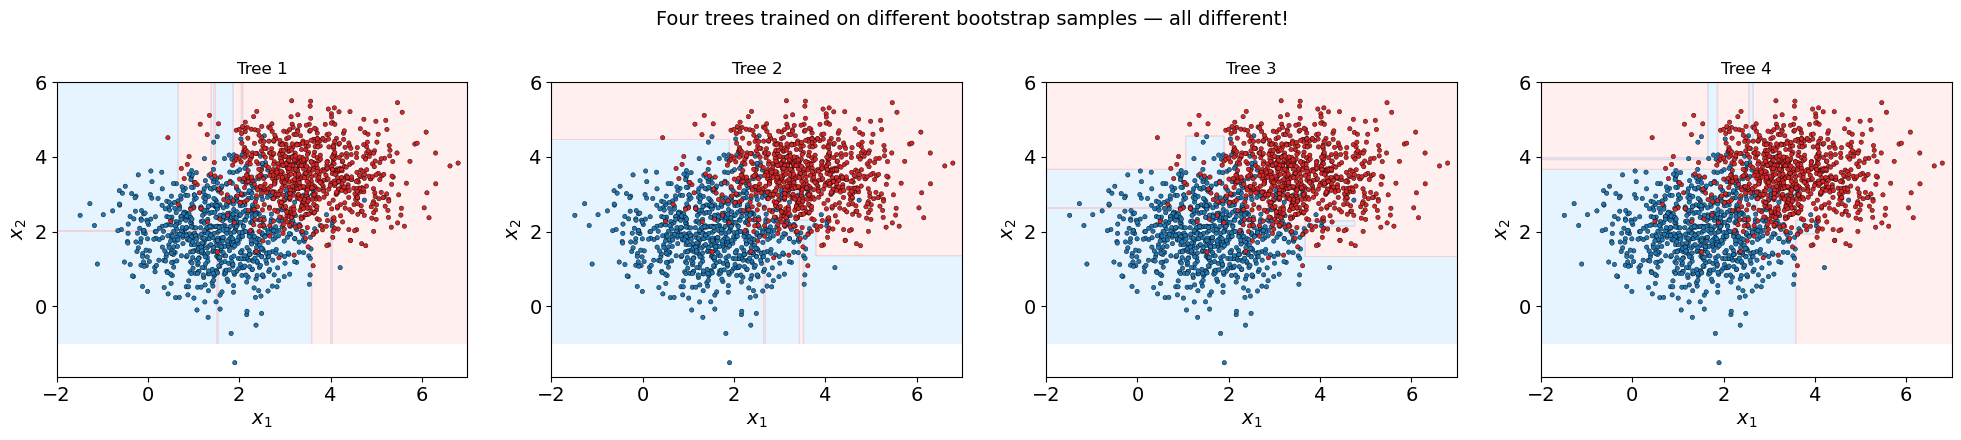

In [6]:
# Generate a dataset
n = 800
X_ens = np.vstack([
    RNG.normal([1.5, 2.0], [1.0, 0.8], (n, 2)),
    RNG.normal([3.5, 3.5], [1.0, 0.8], (n, 2)),
])
y_ens = np.array([0]*n + [1]*n)

# Train 4 trees on different bootstrap samples
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
xx, yy = np.meshgrid(np.linspace(-2, 7, 300), np.linspace(-1, 6, 300))

predictions = []
for i in range(4):
    # Bootstrap sample: sample with replacement
    idx = RNG.choice(len(y_ens), size=len(y_ens), replace=True)
    X_boot, y_boot = X_ens[idx], y_ens[idx]
    
    tree = DecisionTreeClassifier(max_depth=6, random_state=i)
    tree.fit(X_boot, y_boot)
    
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    predictions.append(tree.predict(np.c_[xx.ravel(), yy.ravel()]))
    
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    axes[i].scatter(X_ens[:, 0], X_ens[:, 1], c=y_ens, cmap=cmap_pts,
                   edgecolors='k', s=10, linewidths=0.3)
    axes[i].set_title(f'Tree {i+1}', fontsize=12)
    axes[i].set_xlabel('$x_1$'); axes[i].set_ylabel('$x_2$')

plt.suptitle('Four trees trained on different bootstrap samples — all different!', fontsize=14)
plt.tight_layout()
plt.show()

Each tree has a different jagged boundary. None of them is wrong, exactly — they are all reasonable given their particular training sample. But each one has idiosyncratic quirks.

### The averaging trick

Here is the key idea: if we **average** the predictions of many trees, the quirks cancel out and the smooth underlying boundary emerges.

This works for the same reason that averaging many measurements reduces noise in experimental physics. If each tree's error is partly random (due to the particular training sample it saw), then averaging $B$ trees reduces the variance by roughly $1/B$ — just like averaging $B$ measurements reduces the standard error by $1/\sqrt{B}$.

More precisely: if we have $B$ models with variance $\sigma^2$ and pairwise correlation $\rho$, the variance of their average is:

$$\text{Var}\left(\frac{1}{B}\sum_{b=1}^{B} f_b\right) = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$$

The second term shrinks with $B$. The first term depends on the **correlation** between trees — and this is where randomization becomes critical.

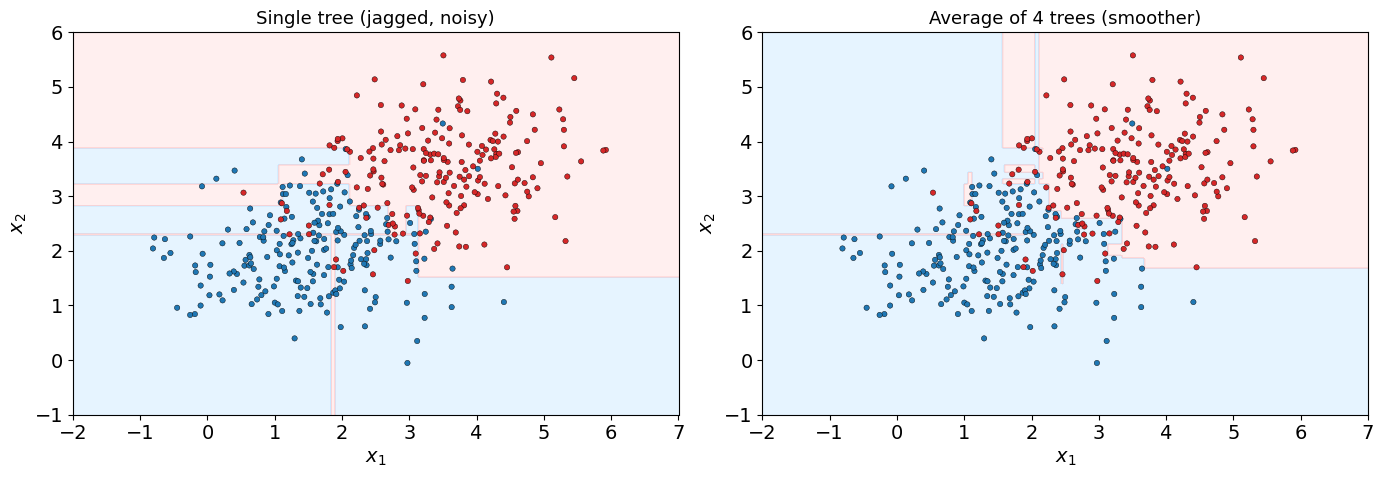

In [3]:
# Average the 4 trees: majority vote
avg_pred = np.mean(predictions, axis=0)
Z_avg = (avg_pred > 0.5).astype(int).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single tree
Z_single = predictions[0].reshape(xx.shape)
axes[0].contourf(xx, yy, Z_single, alpha=0.3, cmap=cmap_bg)
axes[0].scatter(X_ens[:, 0], X_ens[:, 1], c=y_ens, cmap=cmap_pts,
               edgecolors='k', s=15, linewidths=0.3)
axes[0].set_title('Single tree (jagged, noisy)', fontsize=13)
axes[0].set_xlabel('$x_1$'); axes[0].set_ylabel('$x_2$')

# Average of 4 trees
axes[1].contourf(xx, yy, Z_avg, alpha=0.3, cmap=cmap_bg)
axes[1].scatter(X_ens[:, 0], X_ens[:, 1], c=y_ens, cmap=cmap_pts,
               edgecolors='k', s=15, linewidths=0.3)
axes[1].set_title('Average of 4 trees (smoother)', fontsize=13)
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

Even with only 4 trees, the averaged boundary is noticeably smoother. With hundreds of trees, it becomes very smooth indeed.

---
## Part 2: Bagging (Bootstrap Aggregating)

**Bagging** formalizes the idea we just demonstrated. The algorithm:

1. Draw $B$ **bootstrap samples** from the training data (sample with replacement, same size as original)
2. Train one decision tree on each bootstrap sample
3. To predict: have all $B$ trees vote, take the majority

Each bootstrap sample includes about 63% of the original data (the rest are duplicates), so each tree sees a slightly different version of the training set. This is what creates the diversity — and diversity is what makes averaging effective.

### Why 63%?

The probability that a specific sample is **not** selected in any of $N$ draws from $N$ items is $(1 - 1/N)^N \to 1/e \approx 0.368$ as $N \to \infty$. So each bootstrap sample includes about $1 - 1/e \approx 63.2\%$ of unique training points.

In [4]:
# Demonstrate the 63.2% rule
N_samples = [50, 100, 500, 1000, 5000]
print('N_samples  |  Unique fraction  |  Theory (1 - 1/e)')
print('-' * 52)
for N in N_samples:
    boot_idx = RNG.choice(N, size=N, replace=True)
    frac = len(np.unique(boot_idx)) / N
    print(f'{N:>8d}   |     {frac:.4f}        |     {1 - 1/np.e:.4f}')

N_samples  |  Unique fraction  |  Theory (1 - 1/e)
----------------------------------------------------
      50   |     0.6000        |     0.6321
     100   |     0.6100        |     0.6321
     500   |     0.6360        |     0.6321
    1000   |     0.6510        |     0.6321
    5000   |     0.6312        |     0.6321


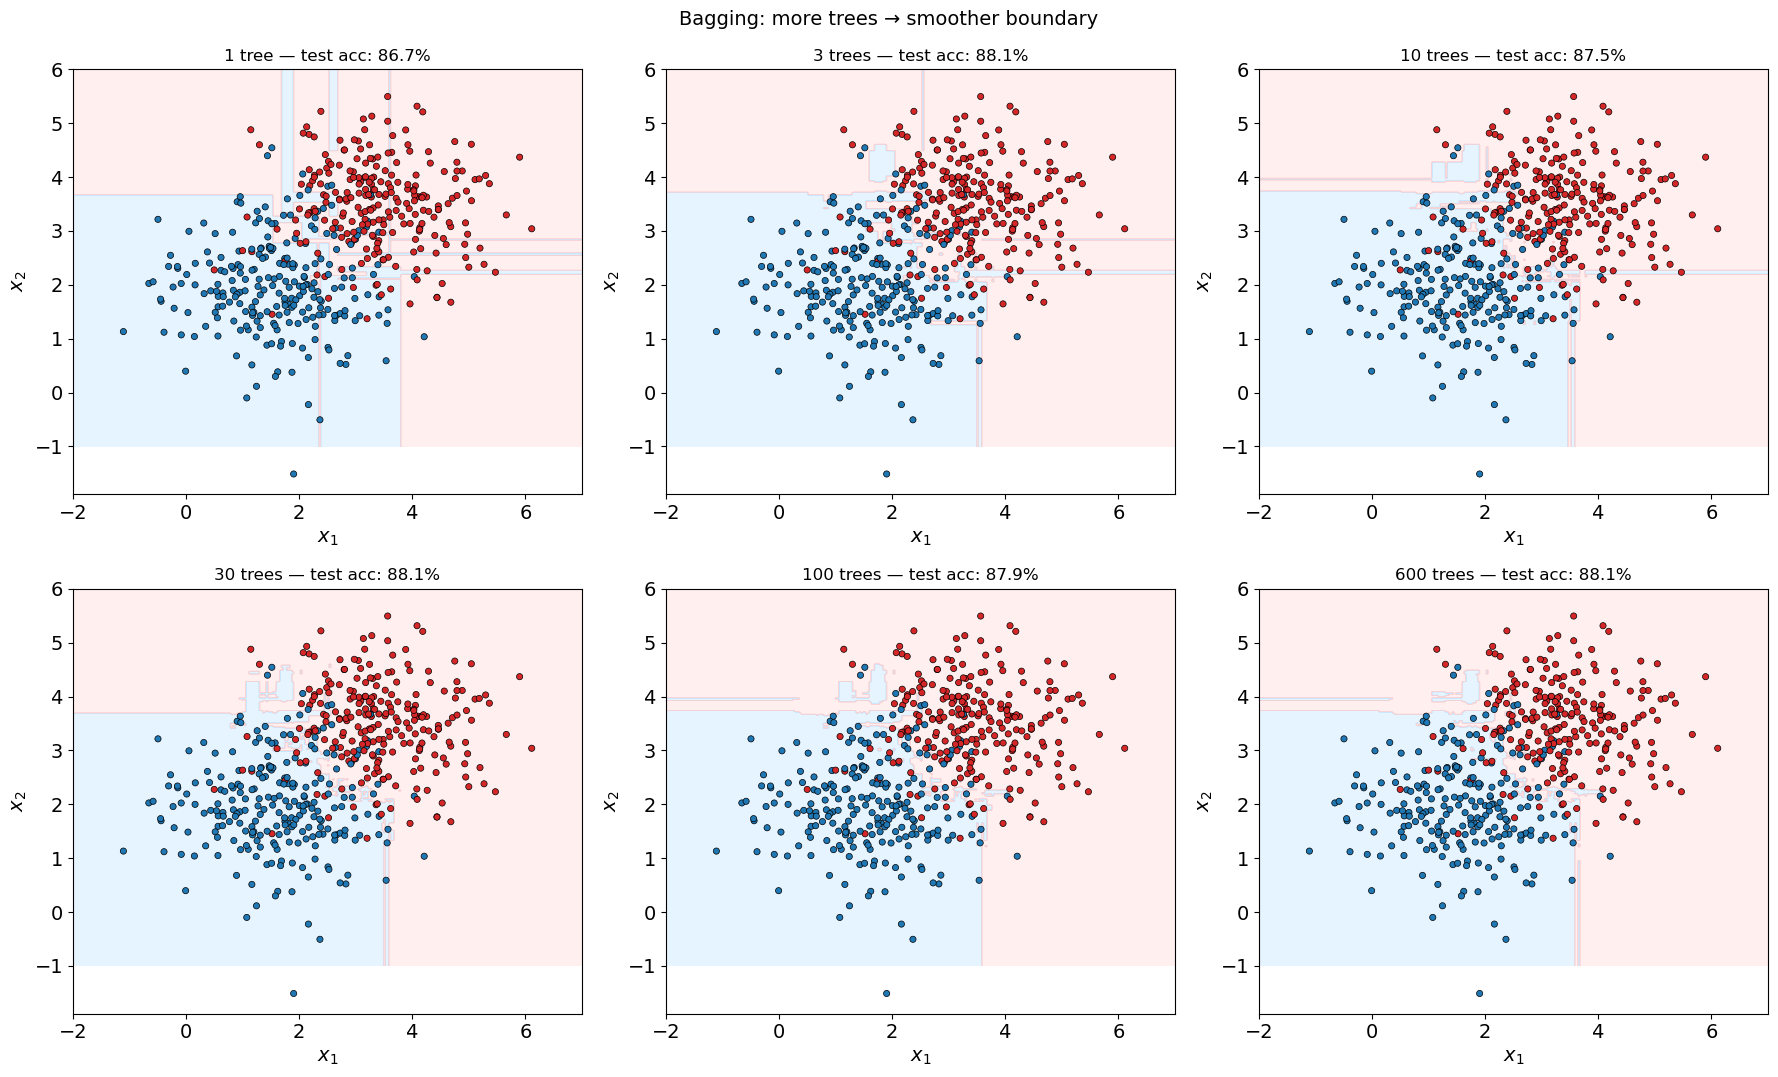

In [7]:
# Bagging in action: vary the number of trees
X_tr_ens, X_te_ens, y_tr_ens, y_te_ens = train_test_split(
    X_ens, y_ens, test_size=0.3, random_state=0, stratify=y_ens
)

n_trees_list = [1, 3, 10, 30, 100, 600]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for i, n_trees in enumerate(n_trees_list):
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=8),
        n_estimators=n_trees, random_state=0
    )
    bag.fit(X_tr_ens, y_tr_ens)
    acc = bag.score(X_te_ens, y_te_ens)
    
    Z = bag.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    axes[i].scatter(X_te_ens[:, 0], X_te_ens[:, 1], c=y_te_ens, cmap=cmap_pts,
                   edgecolors='k', s=20, linewidths=0.5)
    axes[i].set_title(f'{n_trees} tree{"s" if n_trees > 1 else ""} — test acc: {acc:.1%}', fontsize=12)
    axes[i].set_xlabel('$x_1$'); axes[i].set_ylabel('$x_2$')

plt.suptitle('Bagging: more trees → smoother boundary', fontsize=14)
plt.tight_layout()
plt.show()

The boundary gets progressively smoother as we add more trees — the individual trees' quirks cancel out.

### How many trees is enough?

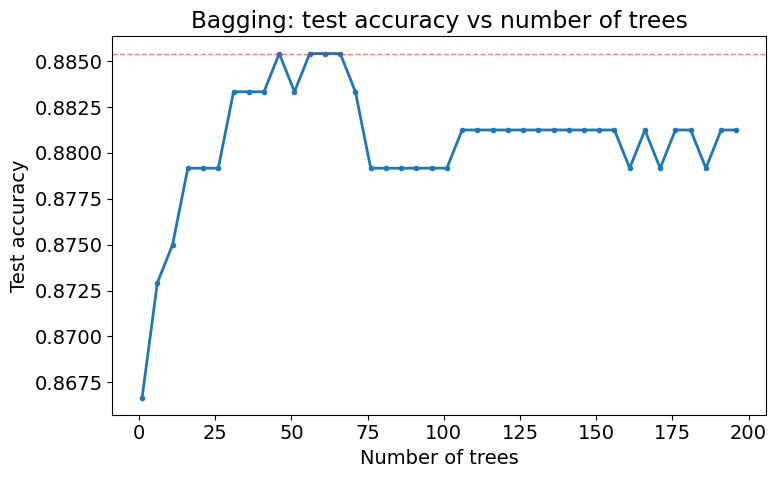

Accuracy saturates quickly — diminishing returns after ~50 trees.
Unlike neural networks, ensembles do NOT overfit as you add more trees.
This is a remarkable property: more trees never hurts.


In [8]:
# Test accuracy vs number of trees
n_range = np.arange(1, 201, 5)
bag_accs = []

for n_t in n_range:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=8),
        n_estimators=n_t, random_state=0
    )
    bag.fit(X_tr_ens, y_tr_ens)
    bag_accs.append(bag.score(X_te_ens, y_te_ens))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_range, bag_accs, 'o-', lw=2, markersize=3)
ax.set_xlabel('Number of trees')
ax.set_ylabel('Test accuracy')
ax.set_title('Bagging: test accuracy vs number of trees')
ax.axhline(max(bag_accs), color='red', ls='--', lw=1, alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Accuracy saturates quickly — diminishing returns after ~50 trees.')
print(f'Unlike neural networks, ensembles do NOT overfit as you add more trees.')
print(f'This is a remarkable property: more trees never hurts.')

**Important:** Unlike increasing the depth of a single tree (which causes overfitting), adding more trees to an ensemble **does not overfit**. The test accuracy plateaus but never decreases. This is because each new tree is trained on a fresh bootstrap sample — it adds information without adding memorization of the same data.

---
## Part 3: Random Forests

Bagging reduces variance by averaging trees trained on different bootstrap samples. But the trees can still be correlated — if one feature is very strong, every tree will split on it first, and the trees end up similar.

**Random forests** add a second source of randomness: at each split, the tree only considers a **random subset of features** (typically $\sqrt{D}$ features out of $D$ total). This forces different trees to use different features, further decorrelating them.

Recall the variance formula:

$$\text{Var}(\text{ensemble}) = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Random feature selection reduces $\rho$ (the correlation between trees), which directly reduces the first term — the one that does not vanish with more trees.

### The random forest algorithm

```
for b = 1 to B:
    1. Draw a bootstrap sample from the training data
    2. Grow a tree, but at each split:
       - Randomly select m features out of D
       - Find the best split among only those m features
    3. Grow the tree fully (no pruning)

To predict: majority vote of all B trees
```

The typical choice is $m = \lfloor\sqrt{D}\rfloor$ for classification and $m = D/3$ for regression.

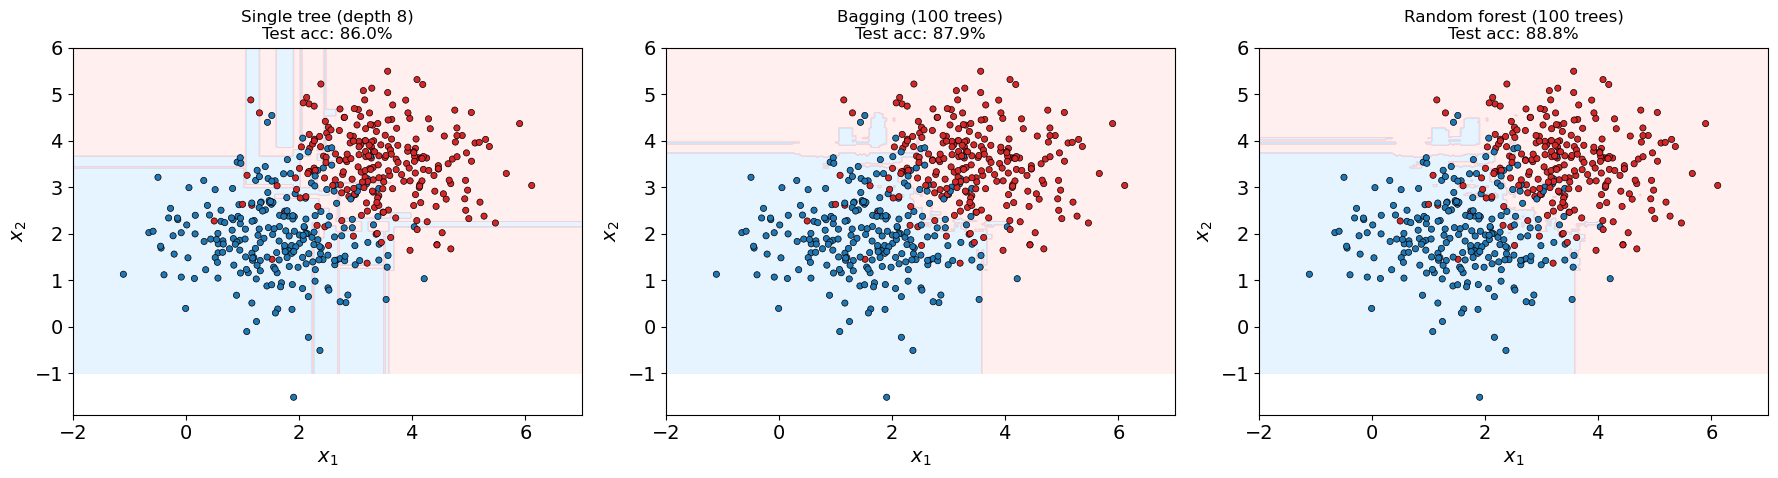

In [9]:
# Random forest on the 2D data
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_tr_ens, y_tr_ens)

# Compare: single tree, bagging, random forest
single_tree = DecisionTreeClassifier(max_depth=8, random_state=0)
single_tree.fit(X_tr_ens, y_tr_ens)

bag100 = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=8),
    n_estimators=100, random_state=0
)
bag100.fit(X_tr_ens, y_tr_ens)

models = [
    ('Single tree (depth 8)', single_tree),
    ('Bagging (100 trees)', bag100),
    ('Random forest (100 trees)', rf),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, models):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    ax.scatter(X_te_ens[:, 0], X_te_ens[:, 1], c=y_te_ens, cmap=cmap_pts,
             edgecolors='k', s=20, linewidths=0.5)
    acc = model.score(X_te_ens, y_te_ens)
    ax.set_title(f'{name}\nTest acc: {acc:.1%}', fontsize=12)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

---
## Breakout Exercise (~20 min)

**Pause here and work with your partner.**

Let us build a random forest from scratch to understand what it does.

1. Create 5 bootstrap samples from the training data (use `RNG.choice` with `replace=True`).
2. Train a `DecisionTreeClassifier(max_depth=None)` on each, but pass `max_features='sqrt'` to restrict the features considered at each split.
3. For 10 test points, collect the 5 predictions and compute the majority vote.
4. Compare the majority vote to each individual tree's prediction. How often do they disagree? How often does the vote get it right when an individual tree gets it wrong?

This is exactly what `RandomForestClassifier` does — you are implementing it by hand.

---
## Part 4: Out-of-Bag Estimation

Each bootstrap sample leaves out about 37% of the training data. These left-out samples are called **out-of-bag (OOB)** samples for that tree. Since the tree never saw them during training, we can use them as a free validation set.

For each training point, we collect the predictions from all the trees for which it was out-of-bag, and take the majority vote. This gives an unbiased estimate of test performance **without needing a separate test set**.

This is conceptually similar to leave-one-out cross-validation, but it comes for free with bagging.

In [10]:
# OOB estimation
rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=0)
rf_oob.fit(X_tr_ens, y_tr_ens)

test_acc = rf_oob.score(X_te_ens, y_te_ens)
oob_acc = rf_oob.oob_score_

print(f'Test accuracy:          {test_acc:.2%}')
print(f'Out-of-bag accuracy:    {oob_acc:.2%}')
print(f'\nThe OOB estimate is close to the test accuracy — it works as a free validation.')

Test accuracy:          88.75%
Out-of-bag accuracy:    90.09%

The OOB estimate is close to the test accuracy — it works as a free validation.


---
## Part 5: Feature Importance

Random forests provide a natural measure of **feature importance**: how much does each feature contribute to reducing impurity across all trees?

For each feature, the importance is the total (weighted) decrease in Gini impurity caused by splits on that feature, averaged over all trees. Features that appear in many trees near the root are the most important.

This is one of the most practically useful outputs of a random forest — it tells you which variables matter, even in high-dimensional problems.

### Permutation importance

An alternative (and often more reliable) approach: for each feature, randomly shuffle its values and measure how much the accuracy drops. A feature is important if shuffling it hurts performance.

This is more robust than the built-in Gini importance, which can be biased toward features with many possible split values.

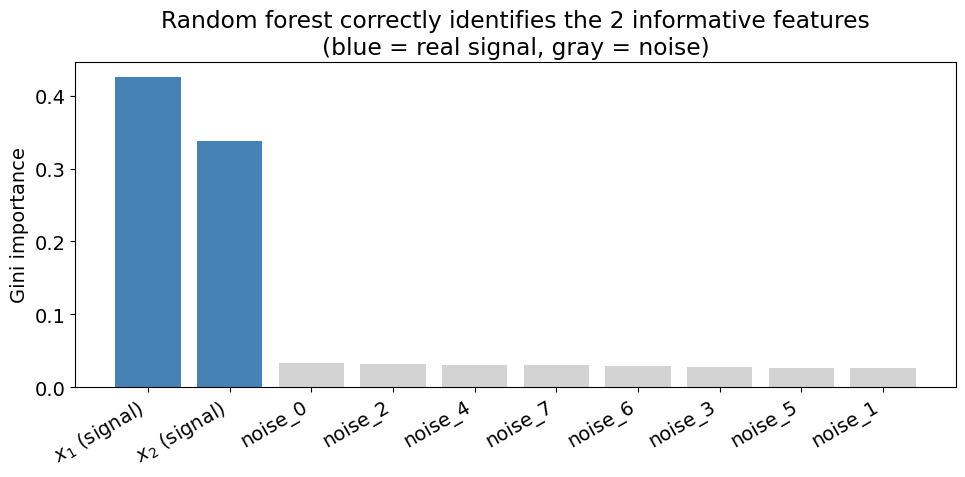


Test accuracy with all 10 features: 89.79%


In [11]:
# Feature importance on a higher-dimensional problem
# Create dataset with 2 informative and 8 noise features
X_imp = np.hstack([
    X_ens,  # 2 informative features
    RNG.standard_normal((len(y_ens), 8))  # 8 noise features
])
feature_names = ['$x_1$ (signal)', '$x_2$ (signal)'] + [f'noise_{i}' for i in range(8)]

X_tr_imp, X_te_imp, y_tr_imp, y_te_imp = train_test_split(
    X_imp, y_ens, test_size=0.3, random_state=0, stratify=y_ens
)

rf_imp = RandomForestClassifier(n_estimators=200, random_state=0)
rf_imp.fit(X_tr_imp, y_tr_imp)

importances = rf_imp.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if i < 2 else 'lightgray' for i in sorted_idx]
ax.bar(range(10), importances[sorted_idx], color=colors)
ax.set_xticks(range(10))
ax.set_xticklabels([feature_names[i] for i in sorted_idx], rotation=30, ha='right')
ax.set_ylabel('Gini importance')
ax.set_title('Random forest correctly identifies the 2 informative features\n'
             '(blue = real signal, gray = noise)')
plt.tight_layout()
plt.show()

print(f'\nTest accuracy with all 10 features: {rf_imp.score(X_te_imp, y_te_imp):.2%}')

The random forest assigns high importance to the two real features and near-zero importance to the noise. This is a powerful tool for **feature selection** in experimental physics: given a large set of candidate variables, the forest tells you which ones actually matter.

### Permutation importance comparison

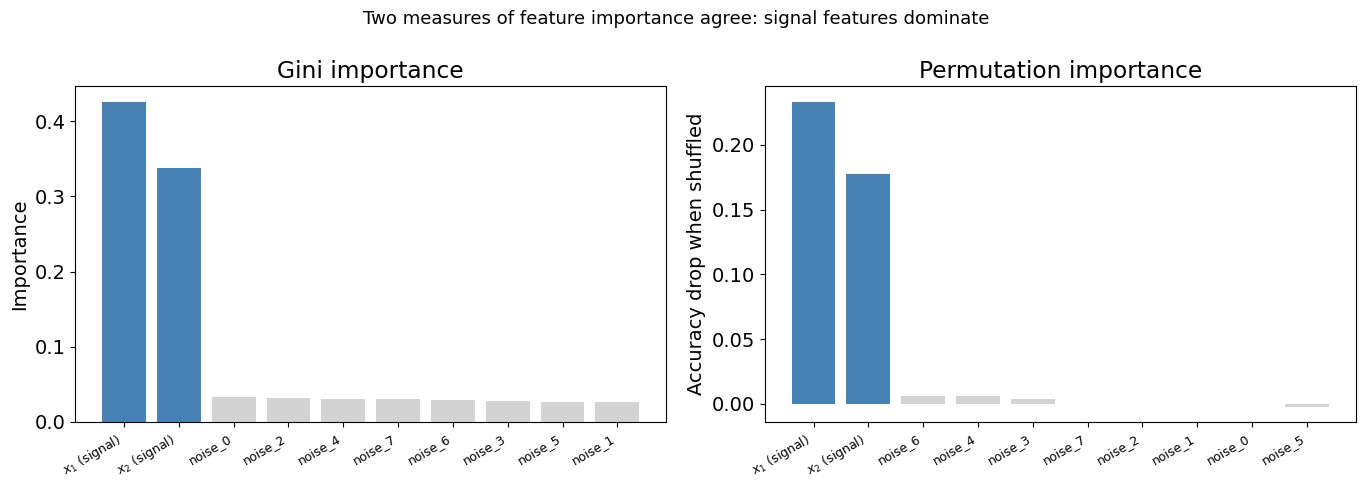

In [12]:
# Permutation importance (manual implementation)
baseline_acc = rf_imp.score(X_te_imp, y_te_imp)
perm_importances = np.zeros(X_te_imp.shape[1])

for j in range(X_te_imp.shape[1]):
    X_perm = X_te_imp.copy()
    X_perm[:, j] = RNG.permutation(X_perm[:, j])  # shuffle feature j
    perm_acc = rf_imp.score(X_perm, y_te_imp)
    perm_importances[j] = baseline_acc - perm_acc  # drop in accuracy

sorted_perm = np.argsort(perm_importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_gini = ['steelblue' if i < 2 else 'lightgray' for i in sorted_idx]
axes[0].bar(range(10), importances[sorted_idx], color=colors_gini)
axes[0].set_xticks(range(10))
axes[0].set_xticklabels([feature_names[i] for i in sorted_idx], rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Importance')
axes[0].set_title('Gini importance')

colors_perm = ['steelblue' if i < 2 else 'lightgray' for i in sorted_perm]
axes[1].bar(range(10), perm_importances[sorted_perm], color=colors_perm)
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([feature_names[i] for i in sorted_perm], rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Accuracy drop when shuffled')
axes[1].set_title('Permutation importance')

plt.suptitle('Two measures of feature importance agree: signal features dominate', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 6: Ising Model — Grand Comparison

Let us apply the random forest to our Ising model classification problem and compare all methods so far.

In [13]:
# Regenerate Ising data
def ising_monte_carlo(L, T, n_steps=5000, rng=None):
    if rng is None:
        rng = RNG
    spins = rng.choice([-1, 1], size=(L, L))
    for step in range(n_steps):
        i, j = rng.integers(0, L, size=2)
        neighbors = (
            spins[(i+1) % L, j] + spins[(i-1) % L, j] +
            spins[i, (j+1) % L] + spins[i, (j-1) % L]
        )
        dE = 2 * spins[i, j] * neighbors
        if dE <= 0 or rng.random() < np.exp(-dE / T):
            spins[i, j] *= -1
    return spins

def generate_ising_dataset(L=10, n_samples_per_phase=500, n_mc_steps=8000):
    T_low = RNG.uniform(1.0, 1.8, size=n_samples_per_phase)
    T_high = RNG.uniform(2.8, 4.0, size=n_samples_per_phase)
    configs, labels, temps = [], [], []
    for T in T_low:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps)
        configs.append(spins.flatten()); labels.append(0); temps.append(T)
        
    for T in T_high:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps)
        configs.append(spins.flatten()); labels.append(1); temps.append(T)
    X = np.array(configs, dtype=np.float64)
    y = np.array(labels)
    T_arr = np.array(temps)
    idx = RNG.permutation(len(y))
    return X[idx], y[idx], T_arr[idx]

print('Generating Ising configurations...')
X_ising, y_ising, T_ising = generate_ising_dataset(L=10, n_samples_per_phase=400, n_mc_steps=8000)
X_tr_is, X_te_is, y_tr_is, y_te_is, T_tr_is, T_te_is = train_test_split(
    X_ising, y_ising, T_ising, test_size=0.3, random_state=0, stratify=y_ising
)

Generating Ising configurations...


                        Method   Test Acc    AUC
-------------------------------------------------------
           Logistic regression   67.50%    0.5242
           Decision tree (d=5)   91.67%    0.9348
     Random forest (200 trees)   98.75%    0.9918


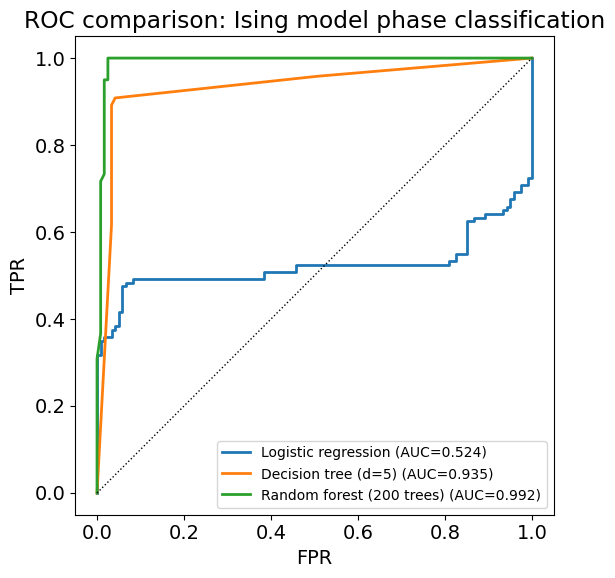

In [14]:
# Train all classifiers
classifiers = {}

# Logistic regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_tr_is, y_tr_is)
classifiers['Logistic regression'] = lr

# Single tree (tuned depth)
tree = DecisionTreeClassifier(max_depth=5, random_state=0)
tree.fit(X_tr_is, y_tr_is)
classifiers['Decision tree (d=5)'] = tree

# Random forest
rf_is = RandomForestClassifier(n_estimators=200, random_state=0)
rf_is.fit(X_tr_is, y_tr_is)
classifiers['Random forest (200 trees)'] = rf_is

# Report results
fig, ax = plt.subplots(figsize=(8, 6))

print(f'{"Method":>30s}   Test Acc    AUC')
print('-' * 55)

for name, clf in classifiers.items():
    acc = clf.score(X_te_is, y_te_is)
    y_prob = clf.predict_proba(X_te_is)[:, 1]
    fpr, tpr, _ = roc_curve(y_te_is, y_prob)
    auc_val = auc(fpr, tpr)
    print(f'{name:>30s}   {acc:.2%}    {auc_val:.4f}')
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC comparison: Ising model phase classification')
ax.legend(fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Feature importance from the random forest

Let us see what the forest considers important for classifying Ising phases.

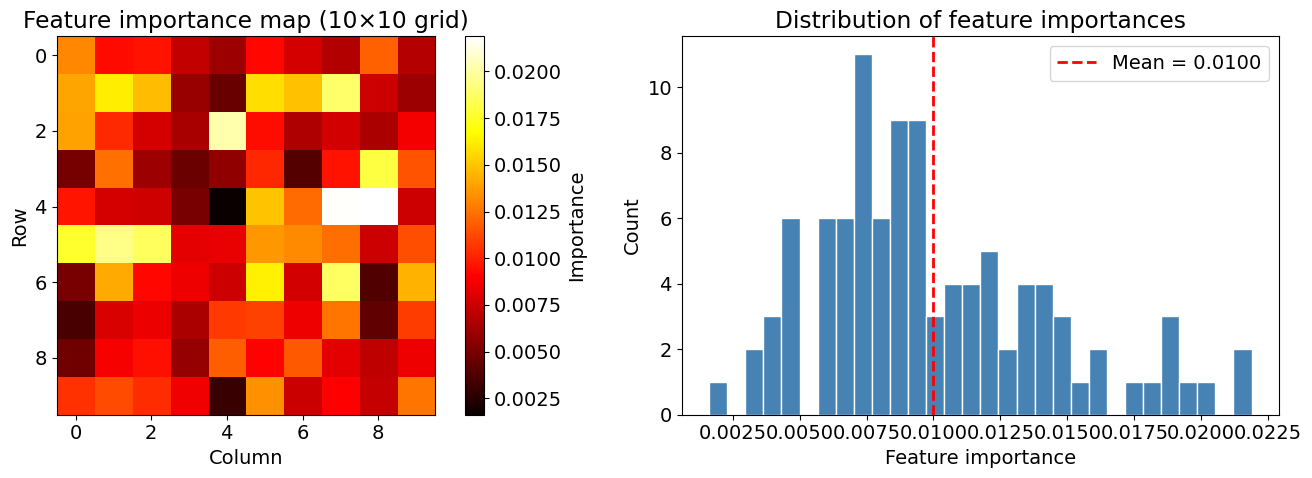

The importances are relatively uniform across spins — the forest uses many spins,
each contributing a little. This reflects the global nature of the order parameter.
No single spin is decisive; the collective behavior matters.


In [15]:
importances_ising = rf_is.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Importance heatmap
im = axes[0].imshow(importances_ising.reshape(10, 10), cmap='hot')
axes[0].set_title('Feature importance map (10×10 grid)')
axes[0].set_xlabel('Column'); axes[0].set_ylabel('Row')
plt.colorbar(im, ax=axes[0], label='Importance')

# Histogram of importances
axes[1].hist(importances_ising, bins=30, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Feature importance')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of feature importances')
axes[1].axvline(importances_ising.mean(), color='red', ls='--', lw=2, 
               label=f'Mean = {importances_ising.mean():.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print('The importances are relatively uniform across spins — the forest uses many spins,')
print('each contributing a little. This reflects the global nature of the order parameter.')
print('No single spin is decisive; the collective behavior matters.')

The relatively flat importance map tells us something interesting: the forest does not rely on any particular spin. Instead, it distributes its splits across many spins — effectively computing a distributed version of the magnetization through many small, local decisions. This is the tree's way of approximating the global quantity $|M|$ without ever computing it explicitly.

---
## Summary

| | Single tree | Bagging | Random forest |
|---|---|---|---|
| **Trees** | 1 | $B$ (on bootstrap samples) | $B$ (bootstrap + random features) |
| **Variance** | High | Reduced | Further reduced |
| **Overfits?** | Yes (with depth) | Less | Less still |
| **Interpretable?** | Yes (fully) | Partially (feature importance) | Partially (feature importance) |
| **Key hyperparameters** | max_depth | n_estimators, max_depth | n_estimators, max_features |

### Key takeaways

- Ensemble methods reduce variance by averaging many models — the same principle as averaging measurements in experimental physics
- Random forests decorrelate trees by restricting features at each split, which is critical for the variance reduction formula
- OOB estimation provides free cross-validation
- Feature importance is a practical tool for variable selection in high-dimensional problems
- Adding more trees **never hurts** (unlike increasing depth of a single tree)

### Looking ahead

Bagging builds trees **in parallel** — each tree is independent. Tomorrow we explore **boosting**, where trees are built **sequentially** — each new tree focuses on correcting the mistakes of the previous ones. This is a fundamentally different strategy and often produces even better results.

---
## Remaining class time: work on HW 6

